# quiz 1 基礎

In [6]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

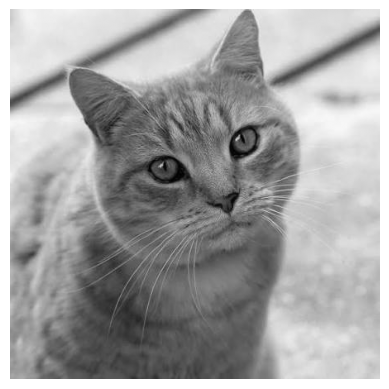

True

In [7]:
image = cv2.imread("./dataset/quiz1_1.jpg")

if image is None:
    raise FileNotFoundError("讀取圖片失敗")

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
plt.show()

Path("result").mkdir(exist_ok=True)
cv2.imwrite("./result/quiz1_1_gray.jpg", gray)

# quiz 1 進階

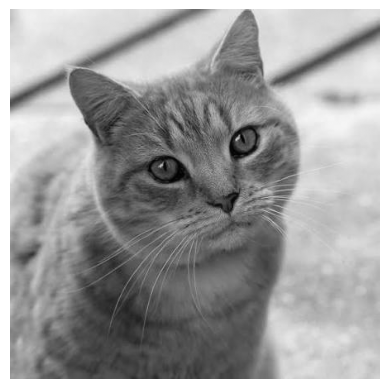

In [9]:
import numpy as np

def grayscale_mean(image):
    height, width = image.shape[:2]
    gray_image = np.zeros((height, width), dtype=np.uint8)
    
    for row in range(height):
        for col in range(width):
            b, g, r = map(int, image[row, col])
            gray_image[row, col] = (r + g + b) // 3
    
    return gray_image

image = cv2.imread("./dataset/quiz1_1.jpg")
gray = grayscale_mean(image)
Path("result").mkdir(exist_ok=True)
cv2.imwrite("./result/quiz1_2_gray.jpg", gray)

plt.imshow(gray, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
plt.show()

執行N次 執行時間取平均

In [ ]:
from time import perf_counter

N = 10
image = cv2.imread("./dataset/quiz1_1.jpg")

# OpenCV
start = perf_counter()
for n in range(N):
    cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
opencv_avg = (perf_counter() - start) / N

# numpy
start = perf_counter()
for n in range(N):
    grayscale_mean(image)
numpy_avg = (perf_counter() - start) / N

print(f"重複次數：{N}")
print(f"OpenCV 平均耗時：{opencv_avg * 1000:.3f} ms")
print(f"自行實作(numpy)平均耗時：{numpy_avg * 1000:.3f} ms")
print(f"平均時間差(自行實作 − OpenCV)：{(numpy_avg - opencv_avg) * 1000:.3f} ms")

重複次數：10
OpenCV 平均耗時：0.101 ms
自行實作(numpy)平均耗時：261.739 ms
平均時間差(自行實作 − OpenCV)：261.637 ms
